In [11]:
import os
os.makedirs("viz", exist_ok=True)

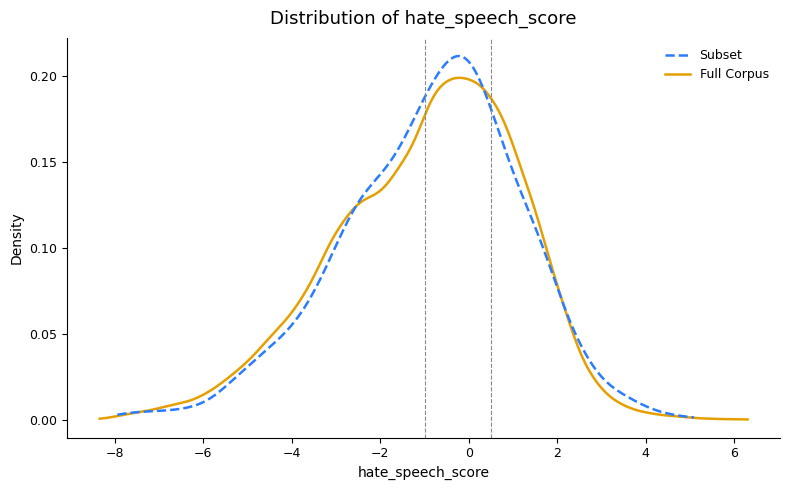

Saved.


In [14]:
import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# load full corpus, aggregate to one score per comment
dataset = datasets.load_dataset('ucberkeley-dlab/measuring-hate-speech')
df_full = dataset['train'].to_pandas()
full_data = df_full.groupby('comment_id')['hate_speech_score'].mean().dropna().values

# load jewish subset
df_jewish = pd.read_csv("data/ucberkeley-dlab_target_jewish.csv")
jewish_data = df_jewish['hate_speech_score'].dropna().values

fig, ax = plt.subplots(figsize=(8, 5))

def plot_kde(ax, data, color, label, thresholds=(-1, 0.5), linestyle='-', zorder=1):
    x = np.linspace(data.min(), data.max(), 500)
    kde = gaussian_kde(data, bw_method='scott')
    y = kde(x)

    ax.plot(x, y, color=color, linewidth=1.8, label=label, linestyle=linestyle, zorder=zorder)

    lo, hi = thresholds
    p_sup = (data < lo).mean()
    p_neu = ((data >= lo) & (data < hi)).mean()
    p_hat = (data >= hi).mean()
    return p_sup, p_neu, p_hat

thresholds = (-1, 0.5)
stats_jewish = plot_kde(ax, jewish_data, "#2B7CFF", 'Subset', thresholds, linestyle='--', zorder=2)
stats_full = plot_kde(ax, full_data, "#E69F00", 'Full Corpus', thresholds, linestyle='-', zorder=1)

for t in thresholds:
    ax.axvline(t, color='#888888', linewidth=0.8, linestyle='--')

ax.set_title('Distribution of hate_speech_score', fontsize=13, pad=10)
ax.set_xlabel('hate_speech_score', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=9)
ax.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('viz/hate_speech_score_distributions.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved.")